# Pattern Recognition 1 - Expert System

**Objectives**

* Create a working image analysis and pattern recognition pipeline
* Object labelisation and feature extraction
* Creating an Expert System for Optical Character Recognition (OCR)

**Libraries needed for this lab**

* Numpy
* Matplotlib
* Scikit-image

(all included in the Anaconda distribution)

## Object detection

Given the following image :

(851, 1068) uint8


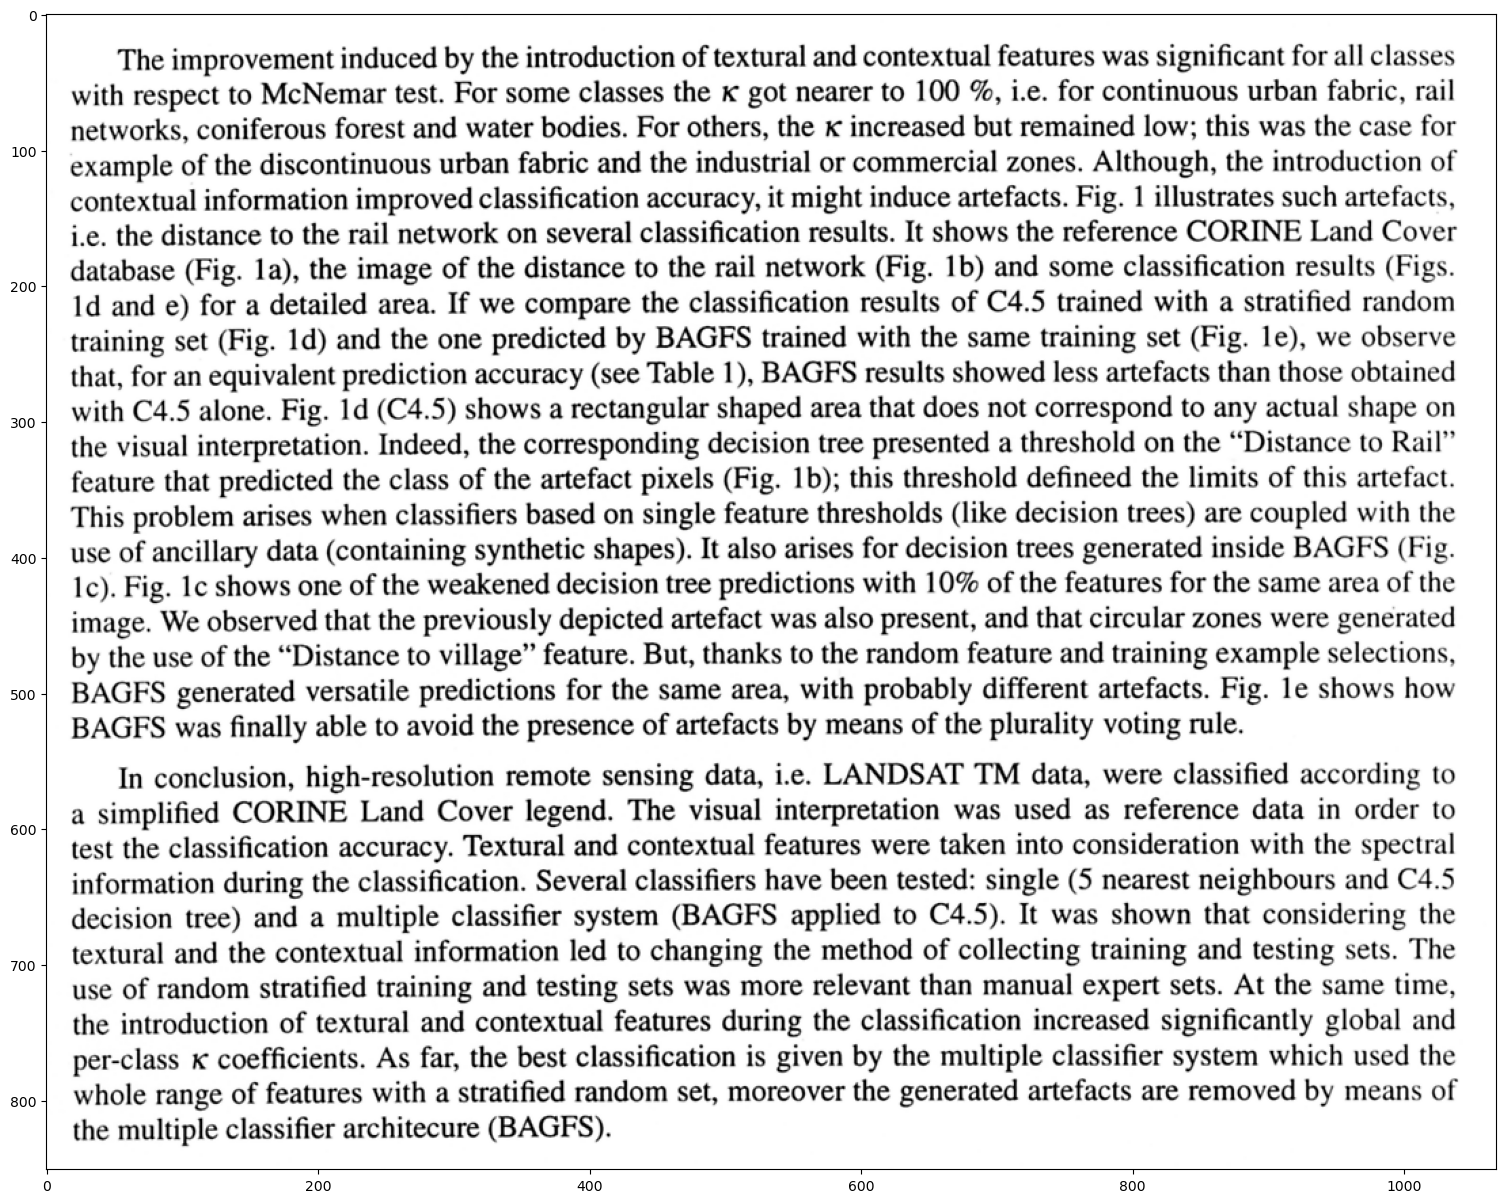

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
%matplotlib inline

im = imread('../data/doc1.png')
print(im.shape, im.dtype)

plt.figure(figsize=(20,15))
plt.imshow(im, cmap=plt.cm.gray)
plt.show()

* **Segment** the image to isolate the text from the background
* **Label individual characters** and **extract** the centroid position, the bounding box, and useful features for each character.

Useful documentation: [`skimage.measure`](http://scikit-image.org/docs/dev/api/skimage.measure.html) module.

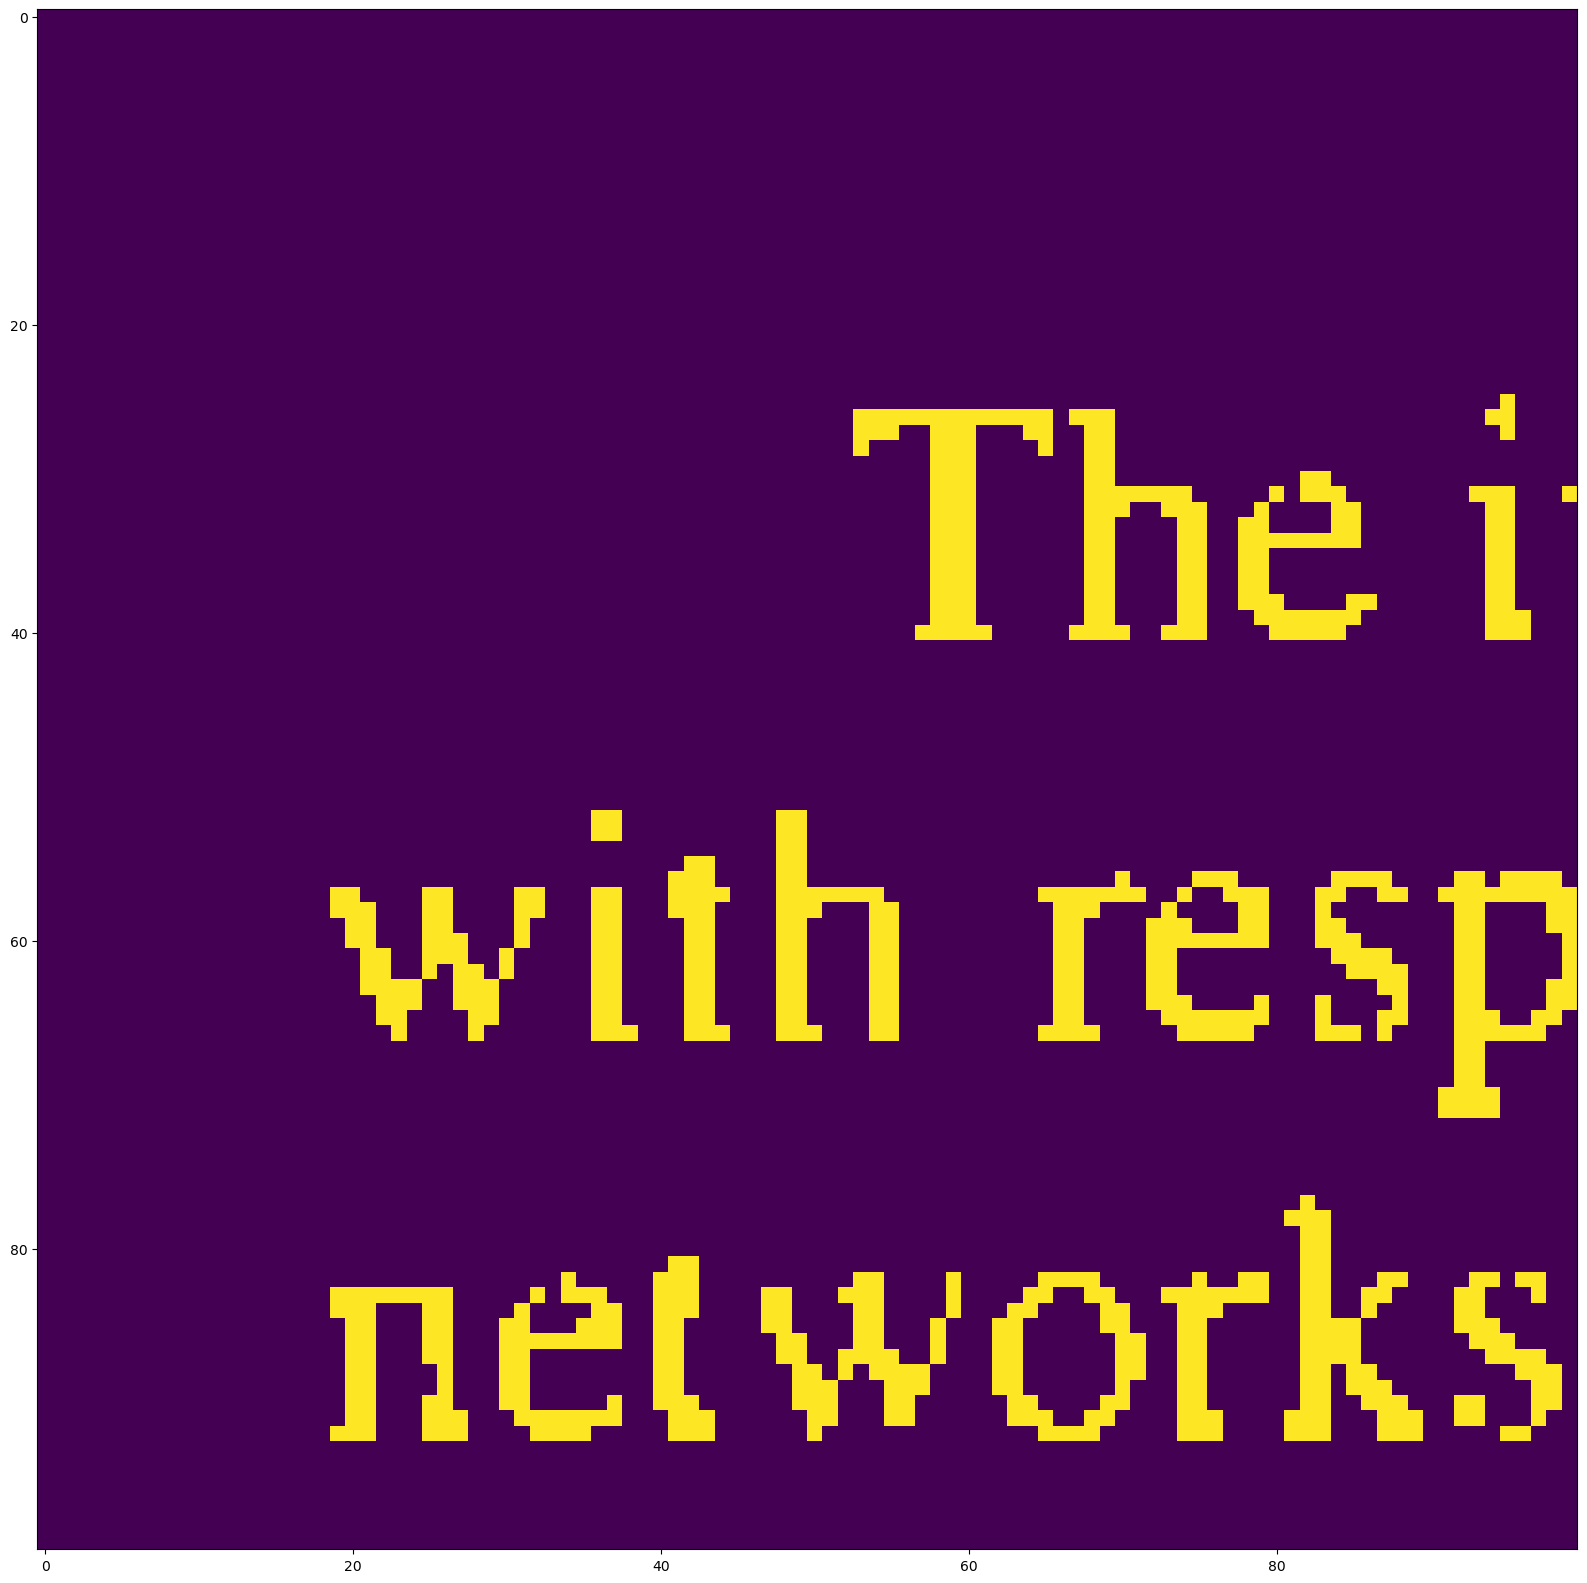

In [2]:
## -- Your code here -- ##

segmented = im < 127
plt.figure(figsize=(20,20))
plt.imshow(segmented[:100, :100])
plt.show()

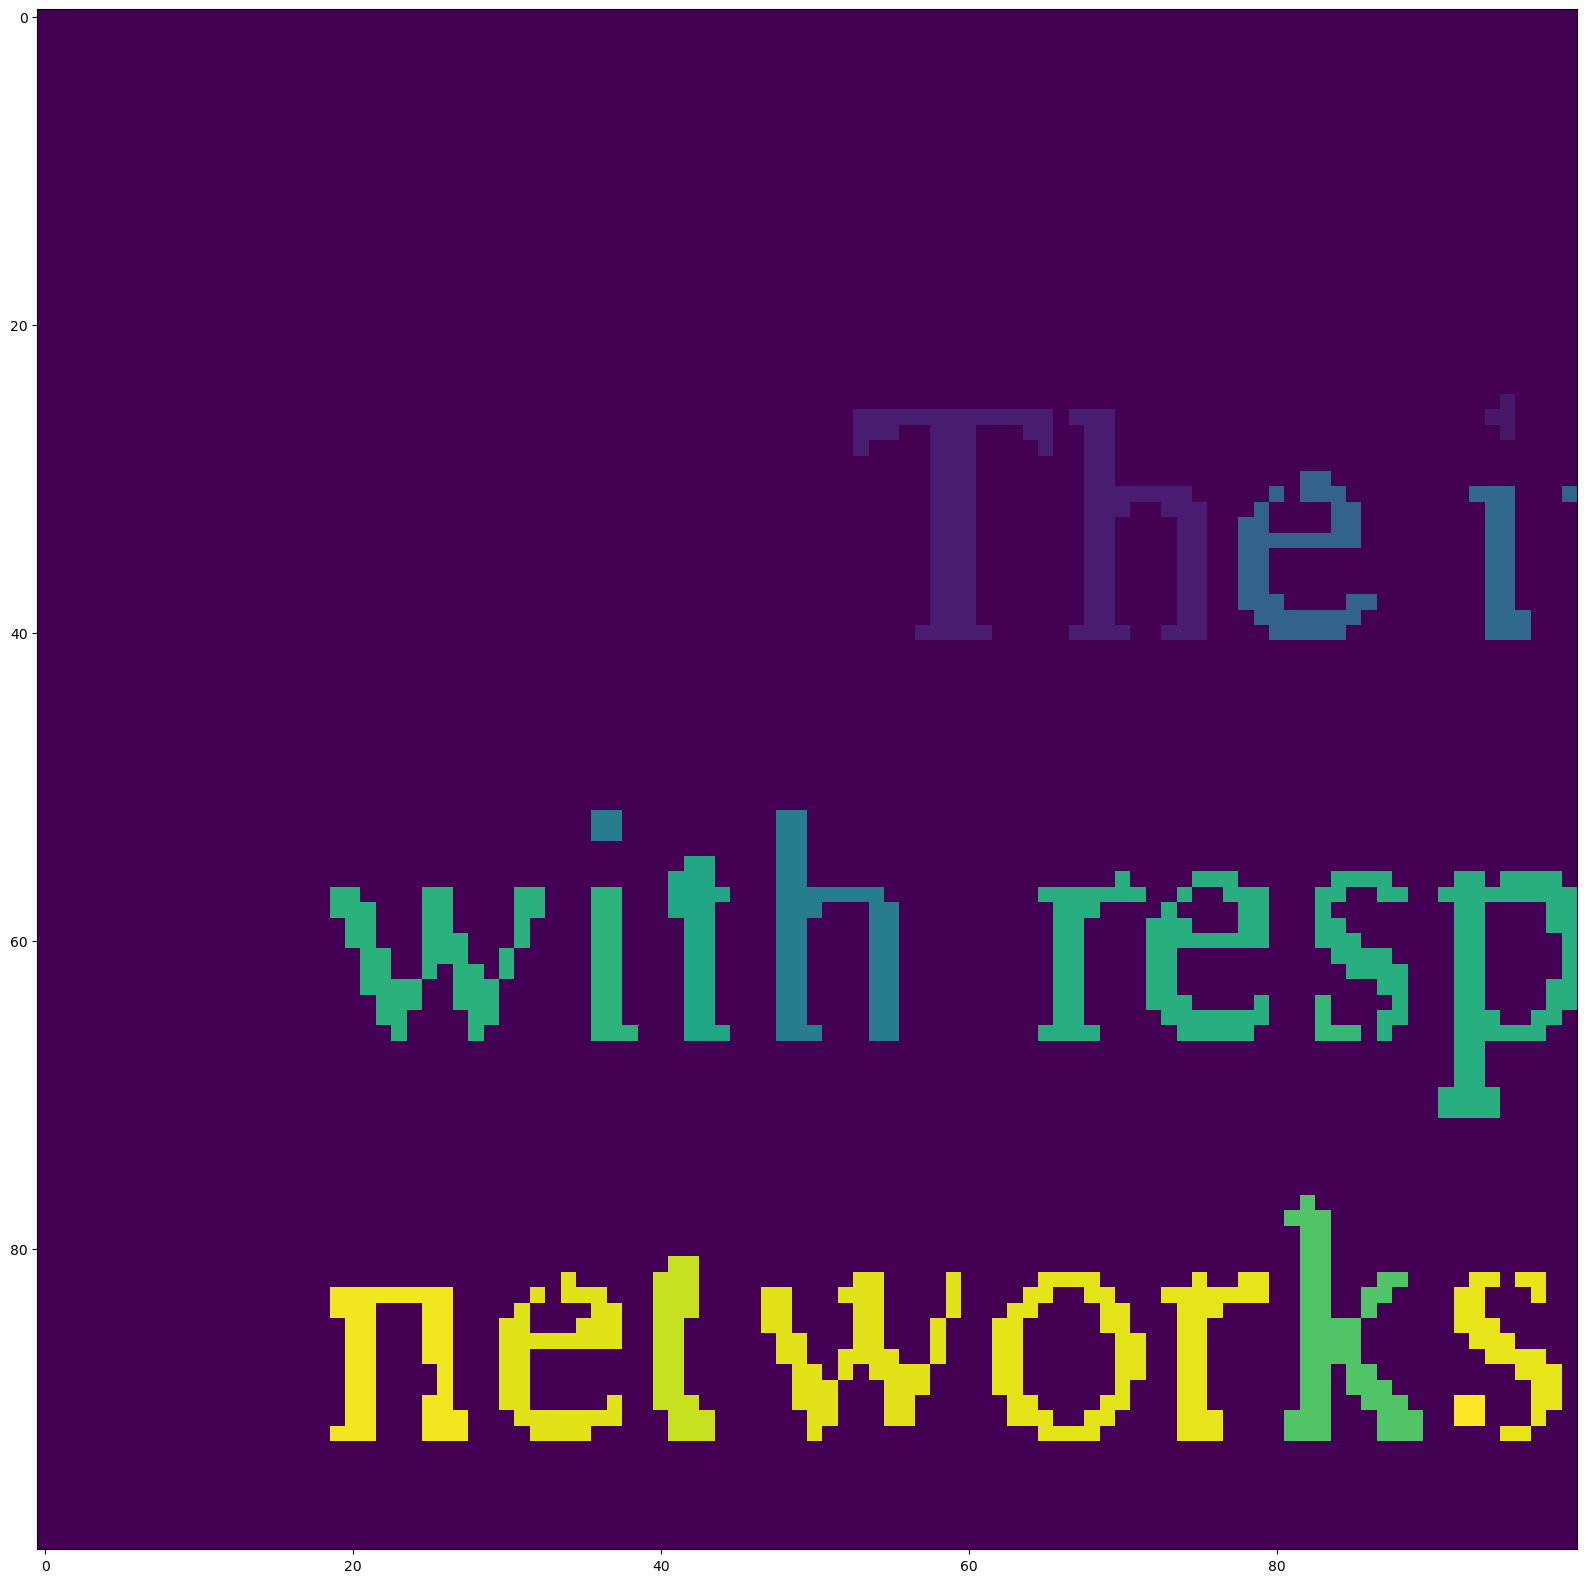

In [3]:
from skimage.measure import label

label_image = label(segmented)

plt.figure(figsize=(20,20))
plt.imshow(label_image[:100, :100])
plt.show()

In [4]:
from skimage.measure import regionprops

object_properties = regionprops(label_image)
#object_properties

for obj in object_properties:
    print(obj["centroid"], obj["bbox"])
    break

(np.float64(29.970588235294116), np.float64(692.4705882352941)) (22, 691, 38, 695)


## Line detection and letter ordering

* Find the labels (objects) that belong to each text line
* Order each character in a text line from left to right

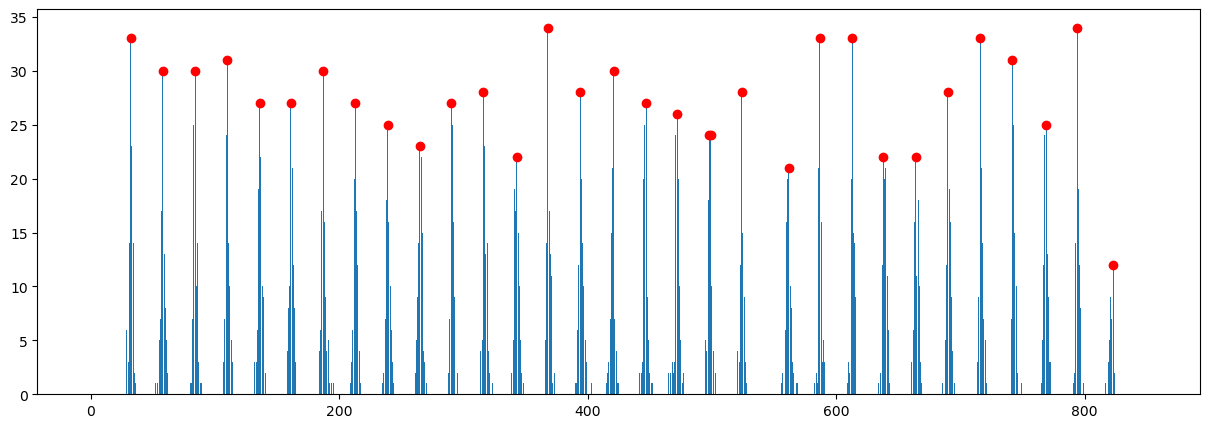

In [5]:
## -- Your code here -- ##

centroid_ys = np.zeros((im.shape[0]))
for obj in object_properties:
    if obj.area < 10:
        continue
    centroid_ys[int(obj["centroid"][0])] += 1

maxima = []
for y in range(3, im.shape[0] - 3):
    if centroid_ys[y] == centroid_ys[y-3:y+3].max() and centroid_ys[y] > 5:
        maxima.append(y)

plt.figure(figsize=(15, 5))
plt.bar(range(im.shape[0]), centroid_ys)
for m in maxima:
    plt.plot(m, centroid_ys[m], 'ro')
plt.show()

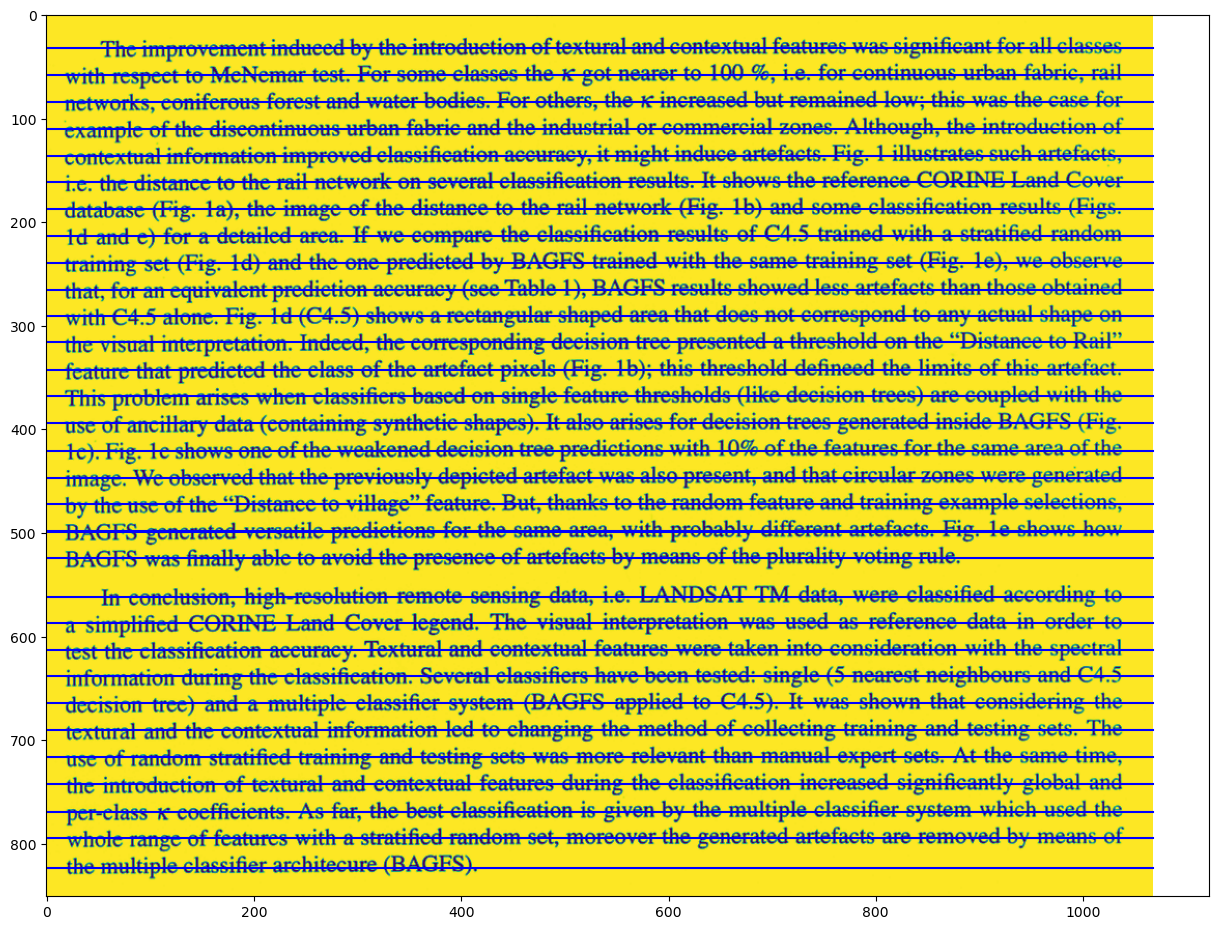

In [6]:
plt.figure(figsize=(15,15))
plt.imshow(im)
for m in maxima:
    plt.plot([0, im.shape[1]], [m, m], 'b-')

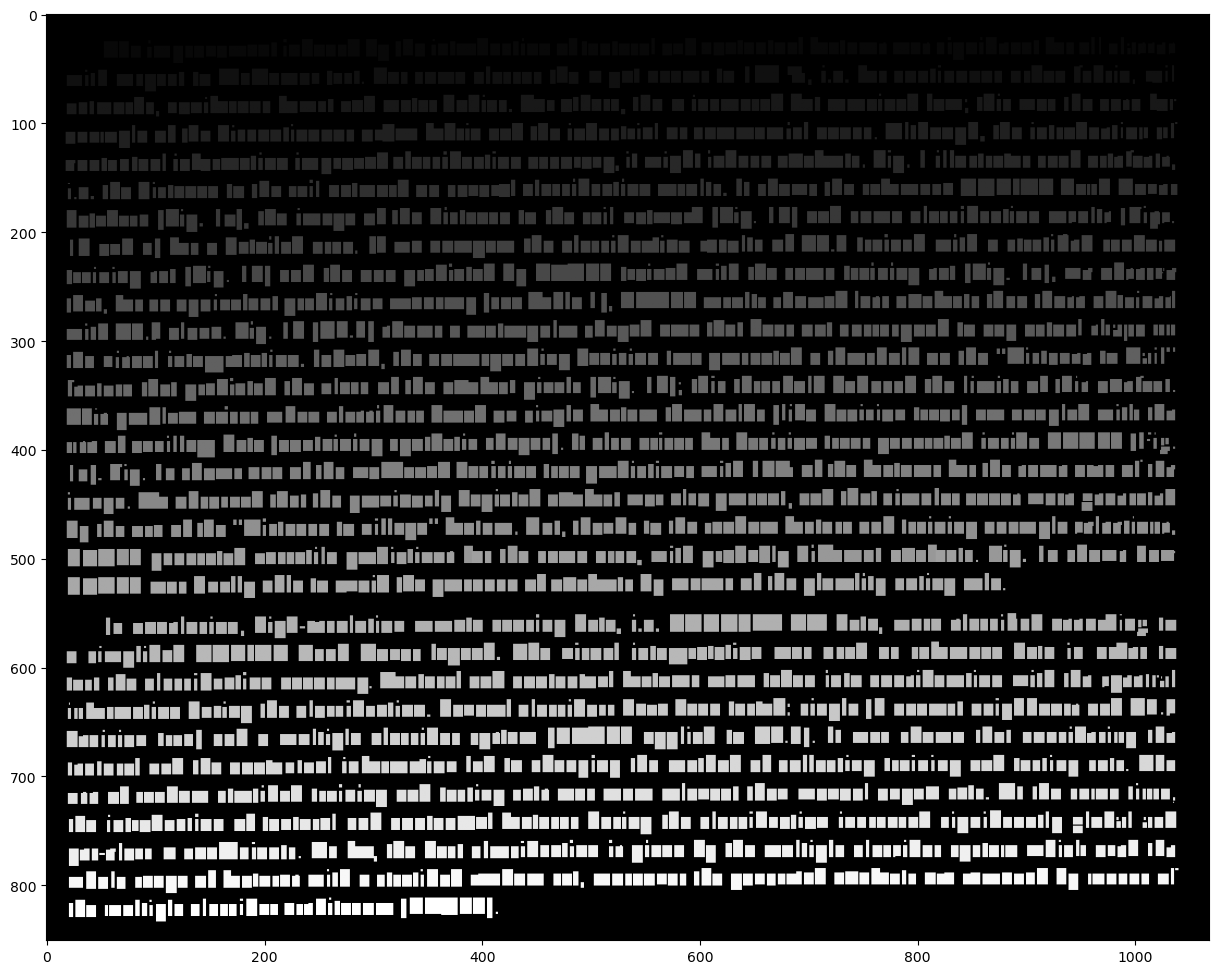

In [7]:
label_to_line = [[] for _ in range(len(maxima))]
maxima = np.array(maxima)
plt.figure(figsize=(15,15))
im_lines = np.zeros(im.shape)
for obj in object_properties:
    closest_line = np.abs(obj.centroid[0] - maxima).argmin()
    label_to_line[closest_line].append(obj)
    im_lines[obj.bbox[0]:obj.bbox[2], obj.bbox[1]:obj.bbox[3]] = closest_line+1
plt.imshow(im_lines, cmap = plt.cm.gray)
plt.show()

In [8]:
ordered_labels = [[] for _ in range(len(maxima))]
for i, line_objects in enumerate(label_to_line):
    x_pos = np.array([obj.centroid[1] for obj in line_objects])
    x_order = x_pos.argsort()

    for x in x_order:
        ordered_labels[i].append(line_objects[x])

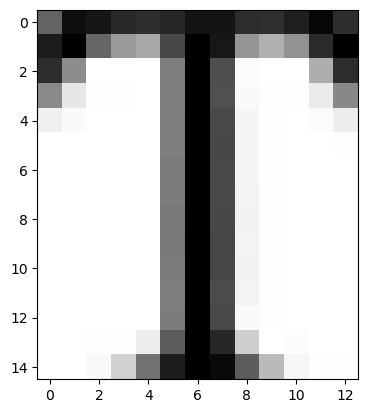

In [9]:
for obj in ordered_labels[0]:
    plt.figure()
    plt.imshow(im[obj.bbox[0]:obj.bbox[2], obj.bbox[1]:obj.bbox[3]], cmap = plt.cm.gray)
    plt.show()
    break

## Expert System classification

* Using the features available with the [regionprops](http://scikit-image.org/docs/dev/api/skimage.measure.html#skimage.measure.regionprops) method of scikit-image, propose a method to automatically recognize some letters.

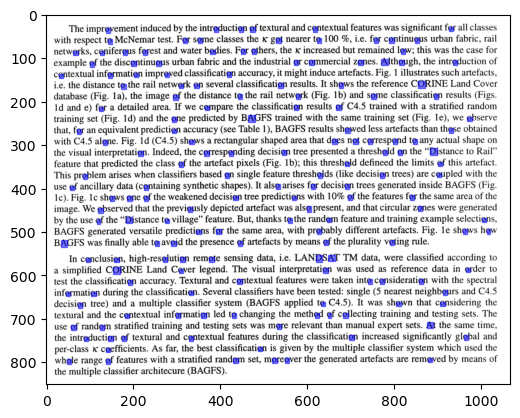

In [10]:
## -- Your code here -- ##

from matplotlib.patches import Rectangle


plt.figure()
plt.imshow(im, cmap=plt.cm.gray)

for idline, line in enumerate(ordered_labels):
    for letter in line:
        bbox = letter.bbox

        # Conditions identiques à ton code original
        if (letter.euler_number == 0 and letter.eccentricity < 0.5):
            plt.gca().add_patch(
                Rectangle(
                    (bbox[1], bbox[0]),
                    bbox[3] - bbox[1],
                    bbox[2] - bbox[0],
                    alpha=0.5,
                    color='blue'
                )
            )

plt.show()


## Full OCR pipeline

Using all the previous exercices, create a method that takes as input a text image, and outputs the recognized text.

In [11]:
def read_letter(letter, idline, maxima):
    bbox = letter.bbox

    if letter.euler_number == -1:
        midline = (maxima[idline] + maxima[idline+1]) / 2 if idline+1 < len(maxima) else maxima[idline]

        if letter.centroid[0] > midline:
            return 'g'

        elif (bbox[3] - bbox[1]) < 15:
            return 'B'

    elif letter.euler_number == 0:
        if letter.eccentricity < 0.5:
            return 'o'

    elif letter.euler_number == 1:
        if letter.axis_minor_length < 3:
            return 'l'

    return '*'

def OCR(im):
    text = ''

    for idline, line in enumerate(ordered_labels):
        for letter in line:
            text += read_letter(letter, idline, maxima)
        text += "\n"
    
    return text

print(OCR(im))

***ll***o******ll***********ll***o****llo*o********l****o*******l********l*l**l*ll*B*l***ll****o*l*ll*lll*ll*llll**lll
*lll***l******o*****l****l**l*o**o***l*********Bo***l*****o***l*llll*l*o**o**ll**o********ll***ll*l*l*lll
****o**l*ll*o*ll***o***o**l**l*********o**l**l*o*o**********ll***************ll****o*ll**ll*l*l**l****l*lll***ll
**l*l**l*o*****ll**o**l***o**l********ll*******l*******ll**o**o*****l**l*o***lol**o*B*****ll***o***l*ll*ll**ll
*lo*******lll**o****llo**l***o*********l****l*o*********ll***llB**l**************l*llBl*ll*l****************l*ll**llllll
lll*l****l**l******o****l*l*l****o**o*******l*l****l****l*o********l****o**l*************o*****l*l******l*
*l****l**l***llBll******ll**B*o*****ll*******o*****l*l****o****llBl***l****o***ll****l****llo***l**l*lll**lllll**llll
l*l******o*l*****ll***l****l*****o*********l****l****llo********o***l****l*****l*********l**l*l**l****l*
**l*ll*ll*B*l****llBl*********o******l*******Bo*****l*ll****l*************l**ll*B*l****llBll**l***o*